In [6]:
import torch

# Configure PyTorch to use the GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if DEVICE.type == 'cuda':
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("Memory Allocated:", torch.cuda.memory_allocated(0))
    print("Memory Cached:", torch.cuda.memory_reserved(0))
else:
    print("No GPU devices found. Running on CPU.")


Using device: cuda
GPU Device Name: Tesla T4
Memory Allocated: 103137792
Memory Cached: 104857600


In [7]:
import kagglehub
path = kagglehub.dataset_download("shamimulislamsunny/isic-2024-dataset")

In [8]:
import os
DATA_DIR = os.path.join(path, "hair_removed/train")
VAL_DIR = os.path.join(path, "hair_removed/test")

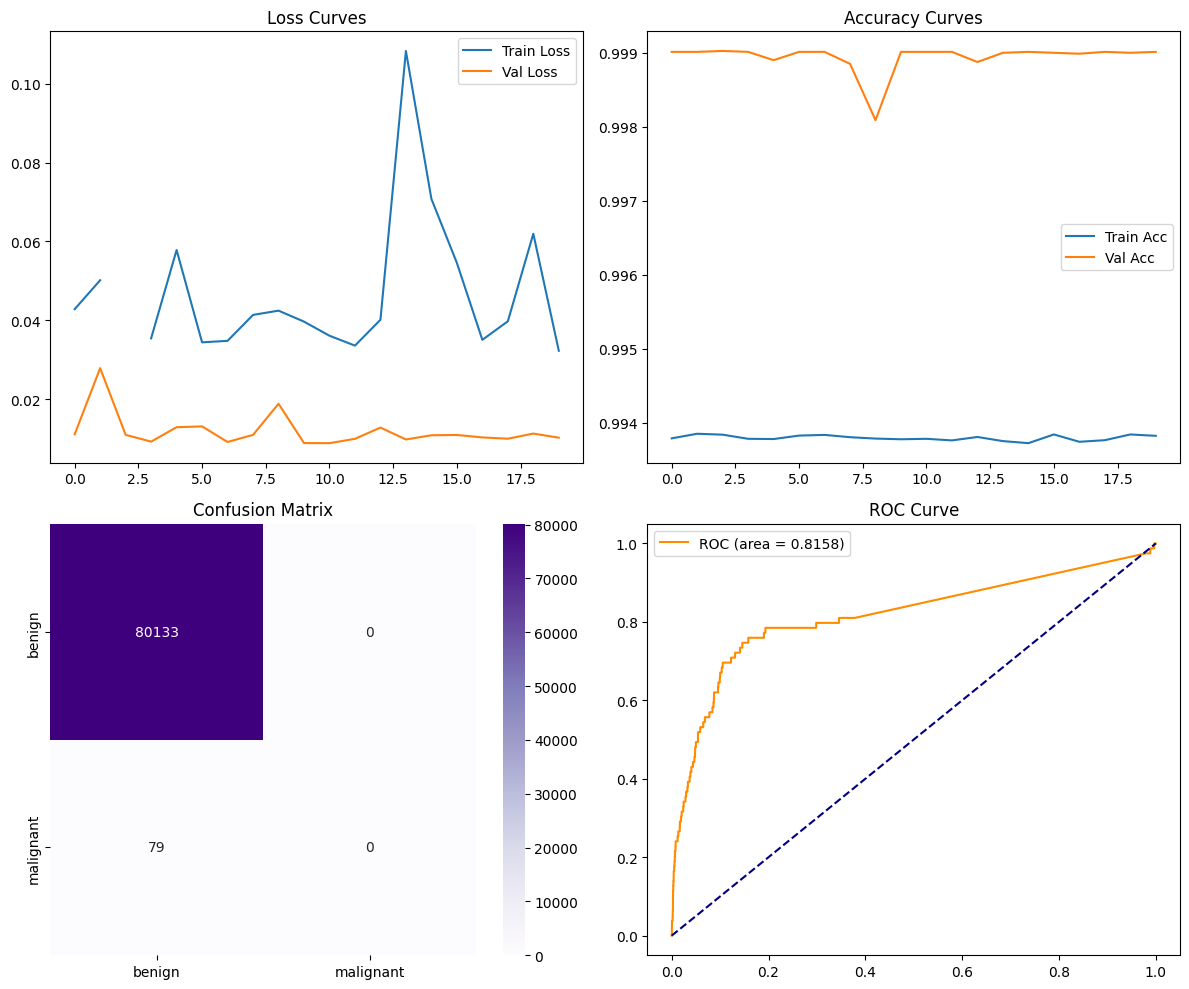


Final ROC-AUC Score: 0.8158
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     80133
   malignant       0.00      0.00      0.00        79

    accuracy                           1.00     80212
   macro avg       0.50      0.50      0.50     80212
weighted avg       1.00      1.00      1.00     80212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# --- SEPARATE EVALUATION SCRIPT (Google Colab Ready) ---

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn

# --- CONFIGURATION ---
CONFIG = {
    "BATCH_SIZE": 32,
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "NUM_WORKERS": 2,
    "MODEL_SAVE_PATH": "/content/drive/MyDrive/ISIC_24/cnn/cnn_isic2024.pth",   # adjust if needed
    "HISTORY_SAVE_PATH": "/content/drive/MyDrive/ISIC_24/cnn/training_history.pth",
    "VAL_DIR": VAL_DIR # Using the global VAL_DIR variable
}

# --- DATA TRANSFORMS ---
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# --- DATASET & LOADER ---
val_dataset = datasets.ImageFolder(root=CONFIG["VAL_DIR"], transform=val_transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=True,
    persistent_workers=True
)
classes = val_dataset.classes

# --- MODEL ARCHITECTURE (must match training) ---
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, len(classes))
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# --- LOAD MODEL & HISTORY ---
model = CNN().to(CONFIG["DEVICE"])
model.load_state_dict(torch.load(CONFIG["MODEL_SAVE_PATH"], map_location=CONFIG["DEVICE"]))
history = torch.load(CONFIG["HISTORY_SAVE_PATH"])

# --- VISUALIZATION ---
plt.figure(figsize=(12, 10))

# Loss Curves
plt.subplot(2, 2, 1)
plt.plot(history["loss"], label='Train Loss')
plt.plot(history["val_loss"], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Accuracy Curves
plt.subplot(2, 2, 2)
plt.plot(history["accuracy"], label='Train Acc')
plt.plot(history["val_accuracy"], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

# --- FINAL EVALUATION ---
model.eval()
y_probs, y_true = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(CONFIG["DEVICE"]), labels.to(CONFIG["DEVICE"])
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_probs.extend(probs)
        y_true.extend(labels.cpu().numpy())

y_true, y_probs = np.array(y_true), np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# Confusion Matrix
plt.subplot(2, 2, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(2, 2, 4)
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

# --- METRICS ---
print(f"\nFinal ROC-AUC Score: {roc_auc:.4f}")
print(classification_report(y_true, y_pred, target_names=classes))